<a href="https://colab.research.google.com/github/mertcandemirr/sql-practice/blob/main/18_09_%C3%B6dev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


----- VERİ SETİ BOYUTU -----
(1010, 9)

----- INFO -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   musteri_id        1010 non-null   int64         
 1   yas               980 non-null    float64       
 2   gelir             960 non-null    float64       
 3   sehir             1010 non-null   object        
 4   abonelik_tipi     1010 non-null   object        
 5   kayit_tarihi      1010 non-null   datetime64[ns]
 6   aylik_harcama     1010 non-null   float64       
 7   memnuniyet_puani  970 non-null    float64       
 8   churn             1010 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 71.1+ KB

----- İLK 5 SATIR -----
   musteri_id    yas    gelir     sehir abonelik_tipi kayit_tarihi  \
0           1  -5.00 20190.69    Ankara         Basic   2022-08-3

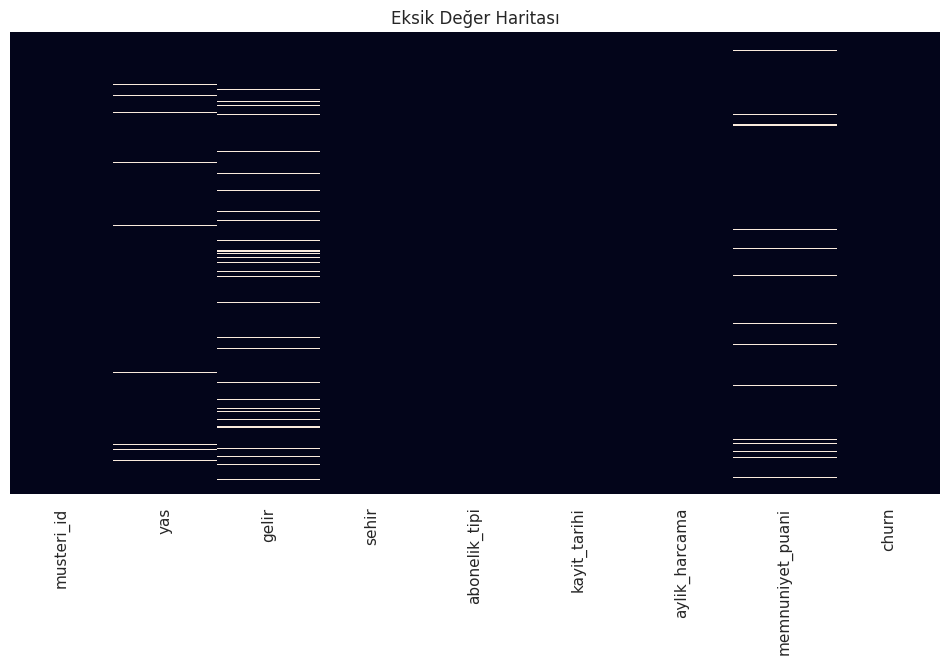


----- DUPLICATE SAYISI -----
10

----- DUPLICATE SATIRLAR -----
      musteri_id   yas    gelir   sehir abonelik_tipi kayit_tarihi  \
1000         341 69.00 49562.37   Bursa         Basic   2022-12-17   
1001         482 51.00 36598.55   Bursa       Premium   2025-06-11   
1002         801 62.00 38019.83  Ankara       Premium   2024-06-18   
1003         365 21.00 47665.61   Bursa         Basic   2025-06-12   
1004         896 30.00 41370.36  Ankara       Premium   2023-03-19   
1005         138 65.00 58725.05  Ankara         Basic   2025-11-11   
1006         906 45.00 56211.84  ANKARA       Premium   2024-04-23   
1007         570 69.00 47371.20   İzmir         Basic   2024-02-16   
1008         488 42.00 44211.00   Bursa       Premium   2025-05-15   
1009         401 65.00 31527.34   Bursa         Basic   2024-06-06   

      aylik_harcama  memnuniyet_puani  churn  
1000        1407.63              1.00      0  
1001        1074.89              3.00      0  
1002        1164.27    

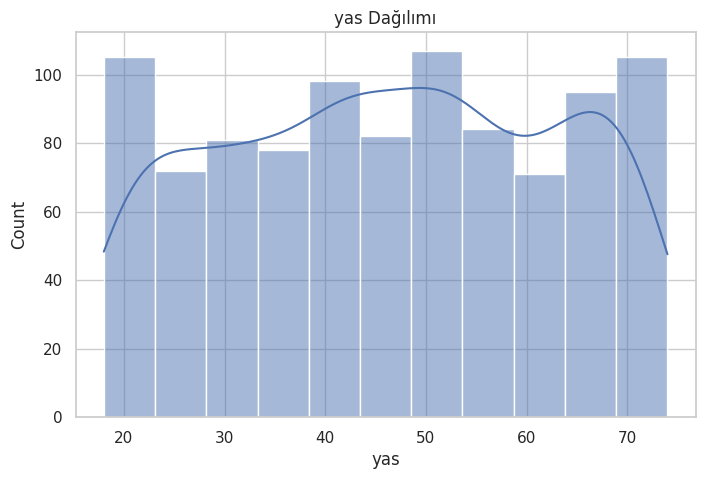

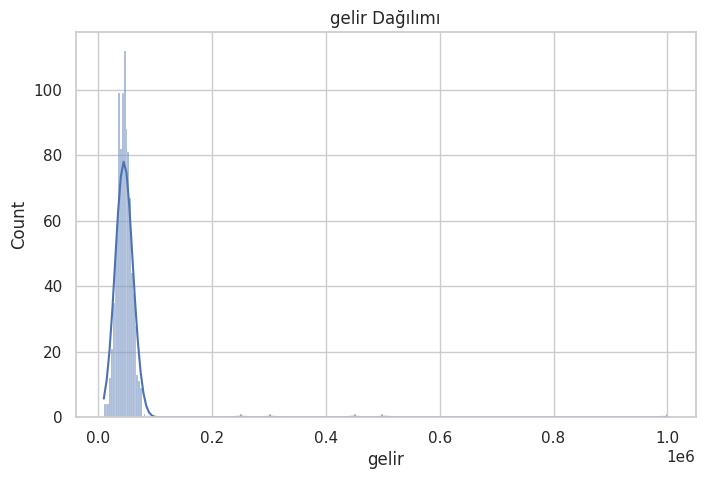

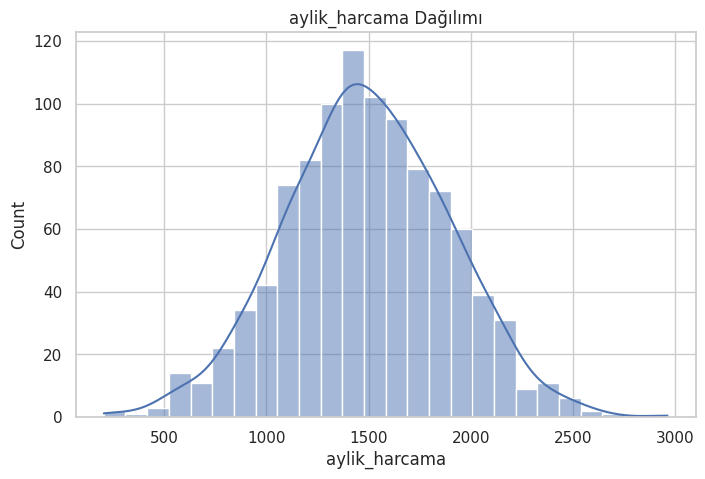

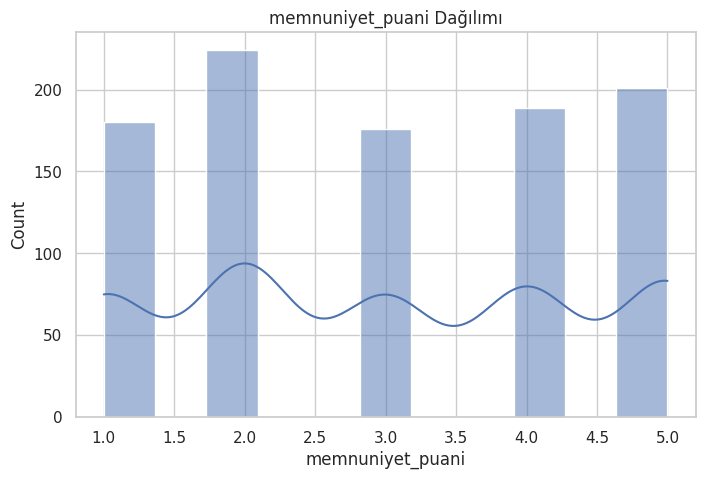

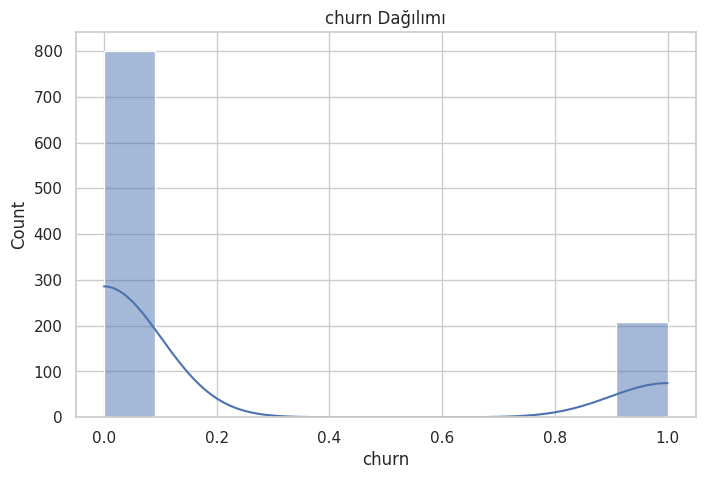

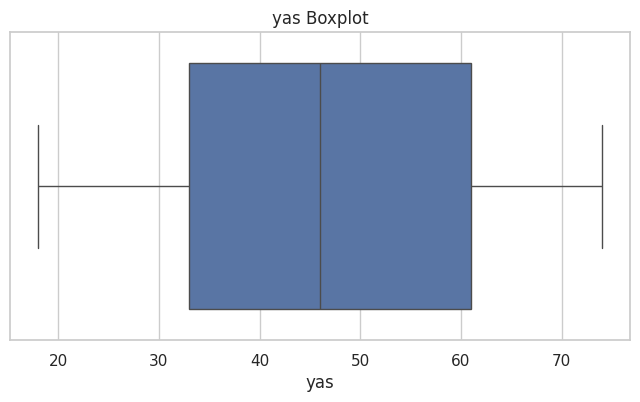

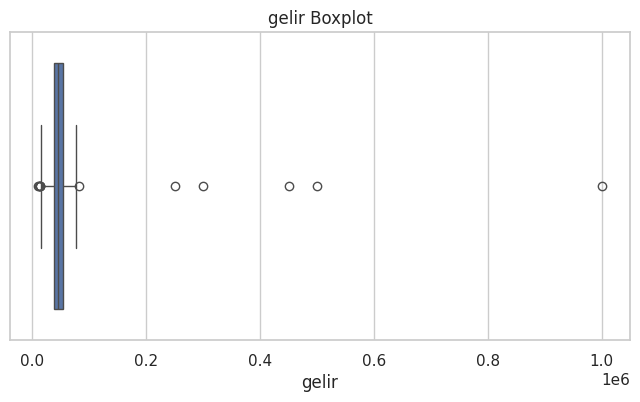

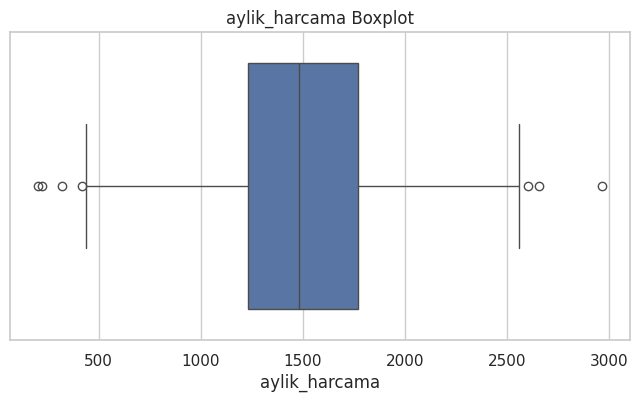

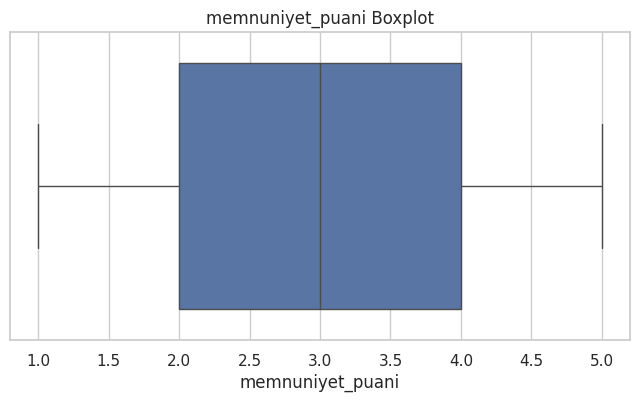

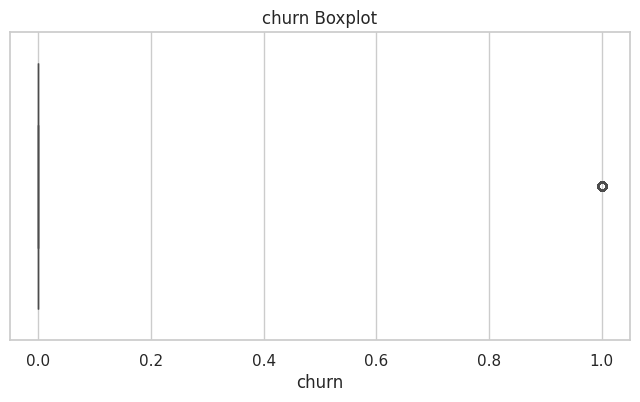


----- KATEGORİK DEĞİŞKENLER -----

--- sehir ---
sehir
ankara      36.14
bursa       16.93
i̇zmir      16.73
i̇stanbul   16.44
istanbul    13.76
Name: proportion, dtype: float64

--- abonelik_tipi ---
abonelik_tipi
Basic      35.05
Premium    32.57
Standard   32.38
Name: proportion, dtype: float64

--- memnuniyet_puani ---
memnuniyet_puani
2.00   23.09
5.00   20.72
4.00   19.48
1.00   18.56
3.00   18.14
Name: proportion, dtype: float64

--- churn ---
churn
0   79.31
1   20.69
Name: proportion, dtype: float64

----- KORELASYON MATRİSİ -----
                   yas  gelir  aylik_harcama  memnuniyet_puani  churn
yas               1.00   0.02          -0.05             -0.01  -0.00
gelir             0.02   1.00           0.01              0.03   0.01
aylik_harcama    -0.05   0.01           1.00              0.01  -0.02
memnuniyet_puani -0.01   0.03           0.01              1.00  -0.01
churn            -0.00   0.01          -0.02             -0.01   1.00


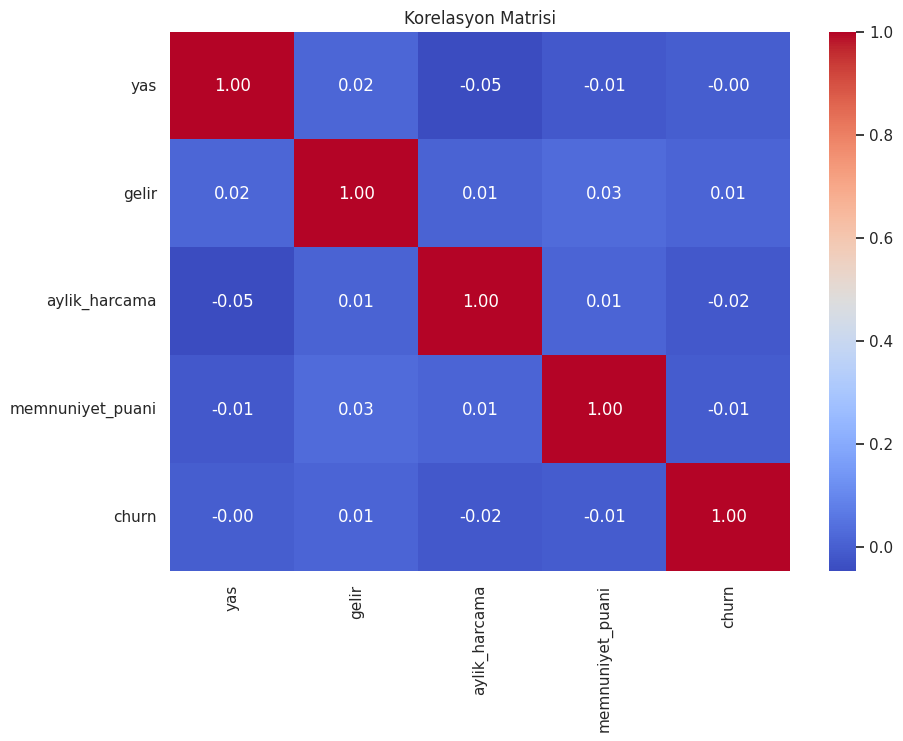

In [1]:

# HAZIRLIK VE ORTAM AYARLARI


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")



# SENTETİK VERİ SETİ OLUŞTURMA


n = 1000

df = pd.DataFrame({
    "musteri_id": range(1, n + 1),

    "yas": np.random.randint(18, 75, n),

    "gelir": np.random.normal(
        loc=45000,
        scale=12000,
        size=n
    ),

    "sehir": np.random.choice(
        ["İstanbul", "istanbul", "Ankara", "ANKARA", "İzmir", "Bursa"],
        n
    ),

    "abonelik_tipi": np.random.choice(
        ["Basic", "Standard", "Premium"],
        n
    ),

    "kayit_tarihi": pd.to_datetime(
        np.random.choice(
            pd.date_range("2022-01-01", "2026-01-01"),
            n
        )
    ),

    "aylik_harcama": np.random.normal(
        1500,
        400,
        n
    ),

    "memnuniyet_puani": np.random.randint(
        1, 6, n
    ),

    "churn": np.random.choice(
        [0, 1],
        n,
        p=[0.8, 0.2]
    )
})



# 3. KİRLİ VERİ EKLEME


# Eksik gelir değerleri
df.loc[
    np.random.choice(df.index, 50, replace=False),
    "gelir"
] = np.nan

# Eksik yaş değerleri
df.loc[
    np.random.choice(df.index, 30, replace=False),
    "yas"
] = np.nan

# Eksik memnuniyet puanları
df.loc[
    np.random.choice(df.index, 40, replace=False),
    "memnuniyet_puani"
] = np.nan


# Gelire aykırı değerler ekleme
outlier_index = np.random.choice(
    df.index,
    5,
    replace=False
)

df.loc[outlier_index, "gelir"] = [
    250000,
    300000,
    450000,
    500000,
    1000000
]


# Mantıksız yaş değerleri
df.loc[0, "yas"] = -5
df.loc[1, "yas"] = 150


# Duplicate satırlar ekleme
duplicate_rows = df.sample(10)

df = pd.concat(
    [df, duplicate_rows],
    ignore_index=True
)



# 4. VERİ SETİNE GENEL BAKIŞ


print("\n----- VERİ SETİ BOYUTU -----")
print(df.shape)

print("\n----- INFO -----")
df.info()

print("\n----- İLK 5 SATIR -----")
print(df.head())

print("\n----- SON 5 SATIR -----")
print(df.tail())

print("\n----- RASTGELE 5 SATIR -----")
print(df.sample(5))



# 5. EKSİK DEĞER ANALİZİ


eksik_ozet = pd.DataFrame({
    "eksik_sayisi": df.isnull().sum(),
    "eksik_yuzdesi": df.isnull().mean() * 100,
    "benzersiz_deger": df.nunique()
})

print("\n----- EKSİK DEĞER ÖZETİ -----")
print(eksik_ozet)


# Eksik değer heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Eksik Değer Haritası")
plt.show()



# 6. DUPLICATE KONTROLÜ


print("\n----- DUPLICATE SAYISI -----")
print(df.duplicated().sum())

print("\n----- DUPLICATE SATIRLAR -----")
print(df[df.duplicated()])



# 7. KATEGORİK VERİ TEMİZLİĞİ


print("\n----- TEMİZLEME ÖNCESİ ŞEHİRLER -----")
print(df["sehir"].value_counts())

df["sehir"] = (
    df["sehir"]
    .str.strip()
    .str.lower()
)

print("\n----- TEMİZLEME SONRASI ŞEHİRLER -----")
print(df["sehir"].value_counts())



# 8. MANTIK DIŞI YAŞ DEĞERLERİ


print("\n----- ANORMAL YAŞ DEĞERLERİ -----")

anormal_yaslar = df[
    (df["yas"] < 0) |
    (df["yas"] > 100)
]

print(anormal_yaslar)


# Mantıksız değerleri NaN yap
df.loc[
    (df["yas"] < 0) |
    (df["yas"] > 100),
    "yas"
] = np.nan



# 9. BETİMSEL İSTATİSTİKLER


print("\n----- BETİMSEL İSTATİSTİKLER -----")
print(df.describe())


# Sayısal sütunları seç
sayisal_sutunlar = (
    df
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

# müşteri_id analiz için anlamlı değil
if "musteri_id" in sayisal_sutunlar:
    sayisal_sutunlar.remove("musteri_id")


# Çarpıklık ve basıklık
print("\n----- ÇARPIKLIK / BASIKLIK -----")

for col in sayisal_sutunlar:
    print(
        f"{col} -> "
        f"skew: {df[col].skew():.2f}, "
        f"kurt: {df[col].kurt():.2f}"
    )



# 10. DAĞILIM GRAFİKLERİ


# Histogram + KDE
for col in sayisal_sutunlar:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(f"{col} Dağılımı")

    plt.show()


# Boxplot
for col in sayisal_sutunlar:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f"{col} Boxplot")

    plt.show()



# 11. KATEGORİK DEĞİŞKEN ANALİZİ


kategorik_sutunlar = [
    "sehir",
    "abonelik_tipi",
    "memnuniyet_puani",
    "churn"
]

print("\n----- KATEGORİK DEĞİŞKENLER -----")

for col in kategorik_sutunlar:

    print(f"\n--- {col} ---")

    print(
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )



# 12. KORELASYON ANALİZİ


corr = df[
    [
        "yas",
        "gelir",
        "aylik_harcama",
        "memnuniyet_puani",
        "churn"
    ]
].corr()

print("\n----- KORELASYON MATRİSİ -----")
print(corr)


plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasyon Matrisi")

plt.show()